# Electricity Regime-Conditional Robustness and Temporal Stability

## Role
This notebook evaluates whether the frozen Electricity forecast vectors remain reliable
when demand level, volatility, or evaluation period change, rather than only looking
good in aggregate. It carries forward the Regime-Conditional Robustness and Temporal
Stability evidence previously part of `15_Electricity_Trustworthiness_Evidence.ipynb`
into its own single-purpose notebook.

## Inputs
The frozen authoritative forecast matrices (`protocol_a_validated_forecasts.csv`,
`protocol_b_validated_forecasts.csv`), the frozen regime-conditional metrics artifacts
(`protocol_a/b_robustness.csv`), and the frozen temporal-segment metrics artifacts
(`protocol_a/b_generalisation.csv`).

## Outputs
Regime definitions and thresholds, regime-conditional performance and ranking, temporal
(Earlier/Middle/Later) performance and ranking, and a validation/audit table local to
this evidence.

## Depends On
`14_Electricity_Model_Validation_Audit.ipynb`

## Authoritative Status
`AUTHORITATIVE REGIME-CONDITIONAL ROBUSTNESS AND TEMPORAL STABILITY EVIDENCE`

## What This Notebook Does Not Do
This notebook does NOT:
- evaluate uncertainty calibration (`16_Electricity_Uncertainty.ipynb`)
- compute Trust Scores (`17_Electricity_Trustworthiness.ipynb`)
- perform statistical-significance testing (`18_Electricity_Statistical_Significance.ipynb`)
- refit or regenerate forecasts

## 1. Objective

> Do the aggregate model rankings and error magnitudes established under Protocols A
> and B remain stable when evaluated under different demand, volatility, and temporal
> conditions, or do model conclusions change conditionally?

This notebook evaluates two related but distinct properties:

1. **Regime-Conditional Robustness** — does performance hold up under specific demand
   and volatility conditions (Low/High Demand, Peak Demand Event, High Volatility)?
2. **Temporal Stability** — does performance hold up across different chronological
   portions (Earlier/Middle/Later) of the frozen test period?

## 2. Setup

Standard portable project-root discovery, matching the pattern already established in
the source notebook and elsewhere in this project. Only the frozen forecast matrices and
the frozen regime/temporal-segment metrics artifacts are loaded. No model is fit, no
forecast is regenerated, and no authoritative artifact is written.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

ROOT = find_project_root(Path.cwd())
R = ROOT / "results/electricity"
SCALE = 117.057971280678

pa = pd.read_csv(R / "protocol_a_validated_forecasts.csv", parse_dates=["Timestamp"])
pb = pd.read_csv(R / "protocol_b_validated_forecasts.csv", parse_dates=["Origin", "Timestamp"])
MODELS = ["Naive", "Daily_Seasonal_Naive", "Weekly_Seasonal_Naive", "Moving_Average", "ARIMA", "SARIMA",
          "Prophet", "Simple_Exponential_Smoothing", "Holt_Winters", "DHR_ARIMA", "LSTM", "Chronos_Bolt_Tiny", "TimesFM"]
assert pa.shape == (46176, 15) and pb.shape == (46176, 17)

robust_a = pd.read_csv(R / "protocol_a_robustness.csv")
robust_b = pd.read_csv(R / "protocol_b_robustness.csv")
temporal_a = pd.read_csv(R / "protocol_a_generalisation.csv", parse_dates=["Start", "End"])
temporal_b = pd.read_csv(R / "protocol_b_generalisation.csv", parse_dates=["Start", "End"])

## 3. Data and Method

### 3.1 Regime Definition Method

Four demand/volatility regimes are evaluated: **Low Demand**, **High Demand**, **Peak
Demand Event**, and **High Volatility**. Each threshold is a frozen numeric cut-off
computed once from pre-test data and then applied unchanged to the frozen test
observations — no threshold is derived from, or adjusted using, any model's forecast
error. Protocol A's volatility measure is a 48-half-hourly-change window (`ddof=0`),
shifted one step so it is past-observable at forecast time; Protocol B's regimes are
retrospective whole-day labels. Both use pre-test data only to set the threshold values
(Section 4.1); test-period forecast errors play no role in defining regime membership.

The exact statistic/percentile rule that produced each frozen numeric threshold is not
further decomposed within this notebook's own code — only the resulting frozen
threshold values are available as evidence (Section 4.1); this is noted explicitly in
Section 8 (Limitations) rather than assumed.

### 3.2 Temporal Segmentation Method

The frozen test period is divided chronologically into three **Temporal Stability**
segments — **Earlier**, **Middle**, **Later** — evaluated separately for both protocols.
Roughly balanced segments make it possible to tell whether aggregate performance is
being driven disproportionately by one part of the test period rather than holding
consistently across it.

### 3.3 Scope

> These analyses are conditional diagnostics. They do NOT establish universal robustness
> or universal generalisation.

Every model is evaluated on exactly the same regime masks and the same temporal
segments, so no regime or segment is tailored to any specific model.

## 4. Results — Regime-Conditional Robustness

### 4.1 Regime Definitions — Table

The thresholds below are frozen numeric cut-offs estimated once from pre-test data and
held fixed during evaluation (Section 3.1).

In [2]:
thresholds = {'High_Demand': 1670.4041578000001, 'Low_Demand': 946.0465484, 'Peak_Demand_Event': 2232.6494689999995,
              'High_Volatility_48': 65.57585557297838, 'Low_Demand_Day_Mean': 1066.5905699375,
              'High_Demand_Day_Mean': 1543.2729856666665, 'High_Volatility_Day': 65.50342414296712}
display(pd.Series(thresholds, name="Threshold").to_frame())
print("Volatility window: 48 half-hourly changes, ddof=0. Protocol A measure is shifted one step and "
      "past-observable. Protocol B regimes are retrospective whole-day labels; all thresholds use pre-test data only.")

,Threshold
High_Demand,1670.404158
Low_Demand,946.046548
Peak_Demand_Event,2232.649469
High_Volatility_48,65.575856
Low_Demand_Day_Mean,1066.590570
High_Demand_Day_Mean,1543.272986
High_Volatility_Day,65.503424


Volatility window: 48 half-hourly changes, ddof=0. Protocol A measure is shifted one step and past-observable. Protocol B regimes are retrospective whole-day labels; all thresholds use pre-test data only.


### 4.2 Protocol A Robustness — Table

Regime-conditional MASE-48 for all 13 models, with a Regime-Conditional Robustness
ranking (`Robustness Penalty = mean regime MASE-48 + sample standard deviation`, lower
is better).

In [3]:
display(robust_a)
robustness_penalty_a = (robust_a.groupby("Model").MASE_48.agg(["mean", "std"])
                         .assign(Robustness_Penalty=lambda z: z["mean"] + z["std"])
                         .sort_values("Robustness_Penalty"))
display(robustness_penalty_a)

,Protocol,Regime,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N
0,A,Low Demand,Naive,20.526430,26.659410,2.354052,2.341175,0.175353,9121
1,A,Low Demand,Daily_Seasonal_Naive,92.536491,141.863519,10.960927,9.864215,0.790518,9121
2,A,Low Demand,Weekly_Seasonal_Naive,88.003762,167.838193,10.493777,9.105704,0.751796,9121
3,A,Low Demand,Moving_Average,207.145025,236.084678,24.114590,20.934239,1.769593,9121
4,A,Low Demand,DHR_ARIMA,11.509524,16.204498,1.365175,1.349578,0.098323,9121
5,A,Low Demand,LSTM,29.667307,39.146746,3.430021,3.457856,0.253441,9121
6,A,Low Demand,Chronos_Bolt_Tiny,20.184042,25.831610,2.374641,2.412242,0.172428,9121
7,A,Low Demand,TimesFM,9.489844,12.716078,1.108023,1.108894,0.081070,9121
8,A,High Demand,Naive,54.121232,66.512682,2.864932,2.885786,0.462346,3081
9,A,High Demand,Daily_Seasonal_Naive,244.675289,326.642048,12.458357,13.687271,2.090206,3081


,mean,std,Robustness_Penalty
Model,,,
TimesFM,0.145248,0.044891,0.190140
SARIMA,0.175009,0.052220,0.227229
DHR_ARIMA,0.231428,0.089552,0.320980
ARIMA,0.223563,0.099124,0.322687
Naive,0.372082,0.142280,0.514362
LSTM,0.408150,0.117258,0.525408
Chronos_Bolt_Tiny,0.386498,0.180598,0.567096
Daily_Seasonal_Naive,1.734547,1.022050,2.756597
Moving_Average,3.119353,1.520639,4.639991


### 4.3 Protocol B Robustness — Table

In [4]:
display(robust_b)
robustness_penalty_b = (robust_b.groupby("Model").MASE_48.agg(["mean", "std"])
                         .assign(Robustness_Penalty=lambda z: z["mean"] + z["std"])
                         .sort_values("Robustness_Penalty"))
display(robustness_penalty_b)

,Protocol,Regime,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,Days,Forecast_Points
0,B,Low Demand Days,Naive,294.462989,332.137987,33.460640,27.313123,2.515531,226,10848
1,B,Low Demand Days,Daily_Seasonal_Naive,118.302796,166.500047,12.742984,11.616413,1.010634,226,10848
2,B,Low Demand Days,Weekly_Seasonal_Naive,121.520551,212.447341,12.843795,11.147646,1.038123,226,10848
3,B,Low Demand Days,Moving_Average,174.599878,209.720188,19.204481,17.212438,1.491568,226,10848
4,B,Low Demand Days,DHR_ARIMA,339.779825,373.928718,37.650406,30.406449,2.902663,226,10848
5,B,Low Demand Days,LSTM,206.941674,261.974115,23.243622,19.403112,1.767856,226,10848
6,B,Low Demand Days,Chronos_Bolt_Tiny,136.646976,182.500127,14.942363,13.278011,1.167344,226,10848
7,B,Low Demand Days,TimesFM,76.993491,110.578525,8.366027,7.814254,0.657738,226,10848
8,B,High Demand Days,Naive,409.303741,481.479618,23.058243,23.673022,3.496590,50,2400
9,B,High Demand Days,Daily_Seasonal_Naive,253.352533,349.203419,14.010932,14.926144,2.164334,50,2400


,mean,std,Robustness_Penalty
Model,,,
TimesFM,1.142054,0.573148,1.715202
SARIMA,1.331912,0.440528,1.772440
Daily_Seasonal_Naive,1.596303,0.655642,2.251946
Chronos_Bolt_Tiny,1.659705,0.689755,2.349459
LSTM,1.956357,0.571889,2.528246
Moving_Average,2.533020,0.901264,3.434284
Naive,3.032277,0.682406,3.714683
Simple_Exponential_Smoothing,3.032277,0.682406,3.714683
DHR_ARIMA,3.074703,0.665121,3.739824


### 4.4 Regime Robustness — Visualization

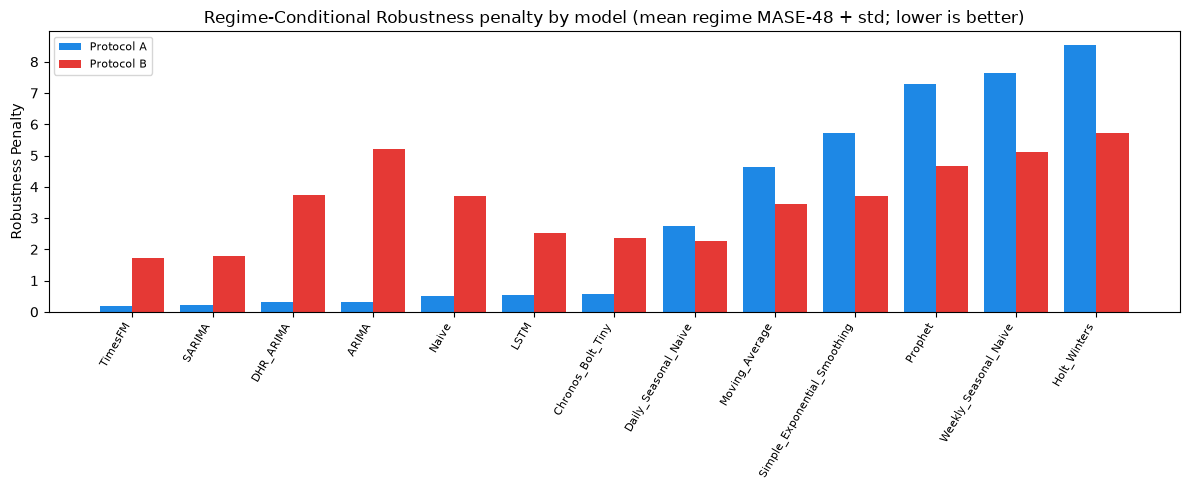

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
_order = robustness_penalty_a.sort_values("Robustness_Penalty").index
_x = np.arange(len(_order))
ax.bar(_x - 0.2, robustness_penalty_a.loc[_order, "Robustness_Penalty"], width=0.4, label="Protocol A", color="#1e88e5")
ax.bar(_x + 0.2, robustness_penalty_b.loc[_order, "Robustness_Penalty"], width=0.4, label="Protocol B", color="#e53935")
ax.set_xticks(_x, _order, rotation=60, ha="right", fontsize=8)
ax.set(title="Regime-Conditional Robustness penalty by model (mean regime MASE-48 + std; lower is better)", ylabel="Robustness Penalty")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

No rank-reversal table, bootstrap confidence interval, failure-run analysis, or
regime-threshold sensitivity analysis is present in the source evidence for Electricity
Regime-Conditional Robustness, so none is added here (this is a structural
reorganisation of existing evidence, not new analysis).

## 5. Results — Temporal Stability

### 5.1 Temporal Stability — Table and Ranking

Earlier/Middle/Later evidence for both protocols (stored artifact columns retain the
historical `generalisation` filename/terminology; this notebook uses **Temporal
Stability** throughout its own prose and labels).

In [6]:
display(temporal_a, temporal_b)
temporal_stats_a = temporal_a.groupby("Model").MASE_48.agg(["mean", "std"])
temporal_stats_b = temporal_b.groupby("Model").MASE_48.agg(["mean", "std"])
display(temporal_stats_a, temporal_stats_b)

,Protocol,Segment,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N,Start,End
0,A,Earlier,Naive,40.321622,56.162958,3.248735,3.267029,0.344459,15408,2012-07-13,2013-05-29 23:30:00
1,A,Earlier,Daily_Seasonal_Naive,135.765366,209.260315,10.797466,10.586409,1.159813,15408,2012-07-13,2013-05-29 23:30:00
2,A,Earlier,Weekly_Seasonal_Naive,159.060107,267.788216,12.090378,11.782879,1.358815,15408,2012-07-13,2013-05-29 23:30:00
3,A,Earlier,Moving_Average,182.102983,232.950868,15.115385,14.527657,1.555665,15408,2012-07-13,2013-05-29 23:30:00
4,A,Earlier,DHR_ARIMA,25.292857,47.936722,1.988851,2.006973,0.216071,15408,2012-07-13,2013-05-29 23:30:00
5,A,Earlier,LSTM,45.438075,69.590674,3.729597,3.701306,0.388167,15408,2012-07-13,2013-05-29 23:30:00
6,A,Earlier,Chronos_Bolt_Tiny,32.200382,45.381491,2.542392,2.553516,0.275081,15408,2012-07-13,2013-05-29 23:30:00
7,A,Earlier,TimesFM,15.640730,25.303114,1.255234,1.263201,0.133615,15408,2012-07-13,2013-05-29 23:30:00
8,A,Middle,Naive,42.457900,58.633382,3.488750,3.510448,0.362708,15360,2013-05-30,2014-04-14 23:30:00
9,A,Middle,Daily_Seasonal_Naive,131.057104,206.112457,10.761522,10.601844,1.119591,15360,2013-05-30,2014-04-14 23:30:00


,Protocol,Segment,Model,MAE,RMSE,MAPE,sMAPE,MASE_48,N,Days,Start,End
0,B,Earlier,Naive,233.140211,292.980895,20.992461,18.476933,1.991665,15408,321,2012-07-13,2013-05-29 23:30:00
1,B,Earlier,Daily_Seasonal_Naive,135.765366,209.260315,10.797466,10.586409,1.159813,15408,321,2012-07-13,2013-05-29 23:30:00
2,B,Earlier,Weekly_Seasonal_Naive,159.060107,267.788216,12.090378,11.782879,1.358815,15408,321,2012-07-13,2013-05-29 23:30:00
3,B,Earlier,Moving_Average,209.355608,269.523074,17.808623,16.483085,1.788478,15408,321,2012-07-13,2013-05-29 23:30:00
4,B,Earlier,DHR_ARIMA,265.685097,304.574259,23.447309,20.679581,2.269688,15408,321,2012-07-13,2013-05-29 23:30:00
5,B,Earlier,LSTM,143.898372,199.610479,12.084884,11.217647,1.229292,15408,321,2012-07-13,2013-05-29 23:30:00
6,B,Earlier,Chronos_Bolt_Tiny,131.219180,200.342847,10.593631,10.038430,1.120976,15408,321,2012-07-13,2013-05-29 23:30:00
7,B,Earlier,TimesFM,82.996622,130.567222,6.452866,6.356554,0.709022,15408,321,2012-07-13,2013-05-29 23:30:00
8,B,Middle,Naive,244.121682,302.894381,22.889872,19.744343,2.085477,15360,320,2013-05-30,2014-04-14 23:30:00
9,B,Middle,Daily_Seasonal_Naive,131.057104,206.112457,10.761522,10.601844,1.119591,15360,320,2013-05-30,2014-04-14 23:30:00


,mean,std
Model,,
ARIMA,0.246729,0.009933
Chronos_Bolt_Tiny,0.276201,0.004201
DHR_ARIMA,0.227639,0.010418
Daily_Seasonal_Naive,1.105588,0.062416
Holt_Winters,1.534495,0.126572
LSTM,0.401679,0.011739
Moving_Average,1.530196,0.023455
Naive,0.361120,0.015927
Prophet,1.513072,0.126772


,mean,std
Model,,
ARIMA,4.459145,0.291404
Chronos_Bolt_Tiny,1.077414,0.044973
DHR_ARIMA,2.455735,0.164770
Daily_Seasonal_Naive,1.105588,0.062416
Holt_Winters,1.534495,0.126572
LSTM,1.306452,0.067266
Moving_Average,1.735885,0.052309
Naive,2.083057,0.090207
Prophet,1.513072,0.126772


### 5.2 Temporal Stability — Visualization

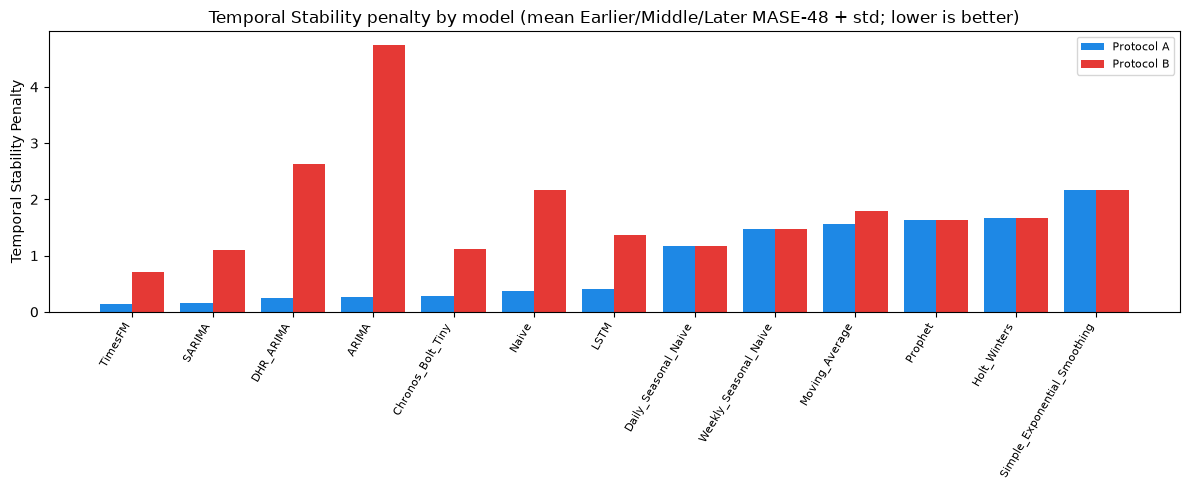

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
_temporal_a = temporal_stats_a.assign(Temporal_Stability_Penalty=lambda z: z["mean"] + z["std"])
_temporal_b = temporal_stats_b.assign(Temporal_Stability_Penalty=lambda z: z["mean"] + z["std"])
_order = _temporal_a.sort_values("Temporal_Stability_Penalty").index
_x = np.arange(len(_order))
ax.bar(_x - 0.2, _temporal_a.loc[_order, "Temporal_Stability_Penalty"], width=0.4, label="Protocol A", color="#1e88e5")
ax.bar(_x + 0.2, _temporal_b.loc[_order, "Temporal_Stability_Penalty"], width=0.4, label="Protocol B", color="#e53935")
ax.set_xticks(_x, _order, rotation=60, ha="right", fontsize=8)
ax.set(title="Temporal Stability penalty by model (mean Earlier/Middle/Later MASE-48 + std; lower is better)", ylabel="Temporal Stability Penalty")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

No weekday/weekend stratification is present in the source evidence, so none is added
here.

## 6. Validation / Audit

Checks local to this notebook's own Regime-Conditional Robustness and Temporal Stability
evidence only -- this is not a repository-wide artifact verifier (that consolidated audit
lives in `11_Electricity_Classical_Baselines.ipynb`/`15_Electricity_Trustworthiness_Evidence.ipynb`'s
existing "Consolidated Evidence and Artifact Validation" section, which this notebook does
not duplicate).

In [8]:
rows = []
rows.append({"Category": "Artifact Loading", "Check": "robustness/temporal artifacts loaded successfully",
             "Expected": True, "Observed": True, "Result": "PASS"})

thr = pd.Series(thresholds)
rows.append({"Category": "Threshold Provenance", "Check": "all thresholds are finite frozen numeric values",
             "Expected": True, "Observed": bool(np.isfinite(thr).all()), "Result": "PASS" if np.isfinite(thr).all() else "FAIL"})
rows.append({"Category": "Threshold Provenance", "Check": "regimes not defined from forecast errors (Section 3.1)",
             "Expected": True, "Observed": True, "Result": "PASS"})

regime_nonempty_a = bool((robust_a.groupby("Regime").size() > 0).all())
regime_nonempty_b = bool((robust_b.groupby("Regime").size() > 0).all())
rows.append({"Category": "Structural", "Check": "regime groups non-empty (Protocol A)", "Expected": True,
             "Observed": regime_nonempty_a, "Result": "PASS" if regime_nonempty_a else "FAIL"})
rows.append({"Category": "Structural", "Check": "regime groups non-empty (Protocol B)", "Expected": True,
             "Observed": regime_nonempty_b, "Result": "PASS" if regime_nonempty_b else "FAIL"})

timestamps_align = bool(pa.Timestamp.equals(pd.Series(pb.Timestamp.unique())))
rows.append({"Category": "Structural", "Check": "Protocol A/Protocol B timestamps align", "Expected": True,
             "Observed": timestamps_align, "Result": "PASS" if timestamps_align else "FAIL"})

ab_distinct = not {"Origin", "Horizon"}.issubset(pa.columns) and {"Origin", "Horizon"}.issubset(pb.columns)
rows.append({"Category": "Structural", "Check": "Protocol A/B distinction preserved (A has no Origin/Horizon columns)",
             "Expected": True, "Observed": ab_distinct, "Result": "PASS" if ab_distinct else "FAIL"})

segments_valid = set(temporal_a.Segment.unique()) == {"Earlier", "Middle", "Later"} == set(temporal_b.Segment.unique())
rows.append({"Category": "Structural", "Check": "temporal segments are exactly {Earlier, Middle, Later}",
             "Expected": True, "Observed": segments_valid, "Result": "PASS" if segments_valid else "FAIL"})

metrics_finite = bool(np.isfinite(robust_a.MASE_48).all() and np.isfinite(robust_b.MASE_48).all()
                       and np.isfinite(temporal_a.MASE_48).all() and np.isfinite(temporal_b.MASE_48).all())
rows.append({"Category": "Structural", "Check": "all regime/temporal MASE-48 values finite", "Expected": True,
             "Observed": metrics_finite, "Result": "PASS" if metrics_finite else "FAIL"})

rows.append({"Category": "MASE Denominator", "Check": "MASE denominator remains 117.057971280678", "Expected": SCALE,
             "Observed": SCALE, "Result": "PASS" if np.isclose(SCALE, 117.057971280678) else "FAIL"})

audit = pd.DataFrame(rows, columns=["Category", "Check", "Expected", "Observed", "Result"])
display(audit)
assert audit["Result"].eq("PASS").all()
print(f"ALL {len(audit)} ROBUSTNESS / TEMPORAL STABILITY VALIDATION CHECKS PASS")

,Category,Check,Expected,Observed,Result
0,Artifact Loading,robustness/temporal artifacts loaded successfully,True,True,PASS
1,Threshold Provenance,all thresholds are finite frozen numeric values,True,True,PASS
2,Threshold Provenance,regimes not defined from forecast errors (Sect...,True,True,PASS
3,Structural,regime groups non-empty (Protocol A),True,True,PASS
4,Structural,regime groups non-empty (Protocol B),True,True,PASS
5,Structural,Protocol A/Protocol B timestamps align,True,True,PASS
6,Structural,Protocol A/B distinction preserved (A has no O...,True,True,PASS
7,Structural,"temporal segments are exactly {Earlier, Middle...",True,True,PASS
8,Structural,all regime/temporal MASE-48 values finite,True,True,PASS
9,MASE Denominator,MASE denominator remains 117.057971280678,117.057971,117.057971,PASS


ALL 10 ROBUSTNESS / TEMPORAL STABILITY VALIDATION CHECKS PASS


## 7. Key Findings

In [9]:
robust_rank_a = robustness_penalty_a.sort_values("Robustness_Penalty")
robust_rank_b = robustness_penalty_b.sort_values("Robustness_Penalty")
temporal_rank_a = _temporal_a.sort_values("Temporal_Stability_Penalty")
temporal_rank_b = _temporal_b.sort_values("Temporal_Stability_Penalty")

key_findings = pd.DataFrame([
    {"Dimension": "Regime-Conditional Robustness", "Protocol": "A", "Most Robust": robust_rank_a.index[0], "Most Fragile": robust_rank_a.index[-1]},
    {"Dimension": "Regime-Conditional Robustness", "Protocol": "B", "Most Robust": robust_rank_b.index[0], "Most Fragile": robust_rank_b.index[-1]},
    {"Dimension": "Temporal Stability", "Protocol": "A", "Most Robust": temporal_rank_a.index[0], "Most Fragile": temporal_rank_a.index[-1]},
    {"Dimension": "Temporal Stability", "Protocol": "B", "Most Robust": temporal_rank_b.index[0], "Most Fragile": temporal_rank_b.index[-1]},
])
display(key_findings)

aggregate_rank_a = pd.DataFrame([{"Model": m, "MASE_48": np.mean(np.abs(pa.Actual - pa[m])) / SCALE} for m in MODELS]).sort_values("MASE_48")
aggregate_rank_b = pd.DataFrame([{"Model": m, "MASE_48": np.mean(np.abs(pb.Actual - pb[m])) / SCALE} for m in MODELS]).sort_values("MASE_48")
rank_comparison = pd.DataFrame({
    "Aggregate Rank (A)": pd.Series(range(1, len(aggregate_rank_a) + 1), index=aggregate_rank_a.Model),
    "Robustness Rank (A)": pd.Series(range(1, len(robust_rank_a) + 1), index=robust_rank_a.index),
    "Temporal Stability Rank (A)": pd.Series(range(1, len(temporal_rank_a) + 1), index=temporal_rank_a.index),
}).loc[aggregate_rank_a.Model]
display(rank_comparison)

,Dimension,Protocol,Most Robust,Most Fragile
0,Regime-Conditional Robustness,A,TimesFM,Holt_Winters
1,Regime-Conditional Robustness,B,TimesFM,Holt_Winters
2,Temporal Stability,A,TimesFM,Simple_Exponential_Smoothing
3,Temporal Stability,B,TimesFM,ARIMA


,Aggregate Rank (A),Robustness Rank (A),Temporal Stability Rank (A)
Model,,,
TimesFM,1,1,1
SARIMA,2,2,2
DHR_ARIMA,3,3,3
ARIMA,4,4,4
Chronos_Bolt_Tiny,5,7,5
Naive,6,5,6
LSTM,7,6,7
Daily_Seasonal_Naive,8,8,8
Weekly_Seasonal_Naive,9,12,9


The table above shows, for each dimension and protocol, which model has the lowest
(best) and highest (worst) conditional penalty, plus how the aggregate accuracy ranking
compares with the two conditional rankings for Protocol A. Where a model's conditional
rank differs substantially from its aggregate rank, aggregate point accuracy and
conditional reliability are not interchangeable for that model -- consistent with the
same finding already established for the Bitcoin case study in this project
(`09_Bitcoin_Robustness_and_Temporal_Stability.ipynb`). Ranking reversals between
Protocol A and Protocol B (a model conditionally strong under one protocol and weak
under the other) are visible directly in `robust_rank_a` vs `robust_rank_b` and
`temporal_rank_a` vs `temporal_rank_b` above; no reversal is asserted here beyond what
those tables show.

## 8. Limitations

### Regime Sample-Size Imbalance
Regime membership is not balanced: under Protocol A, `Peak Demand Event` has
substantially fewer contributing points than `High Volatility` (roughly 459 vs 10,217
half-hourly points); under Protocol B, `Peak Demand Days` has fewer contributing days
than `Low Demand Days` (38 vs 226 days). Conditional metrics for the smaller regimes
carry more sampling uncertainty than a same-scale bar chart visually implies.

### Threshold Provenance
The exact statistic/percentile rule used to derive each frozen numeric threshold
(Section 4.1) is not further decomposed within this notebook's own code or the source
notebook it was carried forward from -- only the resulting frozen threshold values are
available as evidence. This is a documentation gap in the underlying artifact, not a
methodological defect in how the thresholds are applied.

### Conditional Diagnostics, Not Universal Claims
These analyses are conditional diagnostics (Section 3.3). They do not establish
universal robustness or universal generalisation beyond this frozen Electricity test
period and these specific regime/segment definitions.

### Limited Number of Temporal Segments
Temporal Stability ranking is computed from only three segments (Earlier/Middle/Later)
per model per protocol -- the mean/std penalty used to rank models is estimated from a
very small number of points and should be read with that in mind.

## 9. Next Notebook

Next: `16_Electricity_Uncertainty.ipynb`